# 01 - Exploratory Data Analysis & Data-Leakage Verification
**Paper reproduced:** Bhagat, A., Sharma, A., & Agarwal, S. (2025). "An efficient stacking-based ensemble technique for early heart attack prediction." *Multimedia Tools and Applications*, 84, 36351-36375.

This notebook loads the dataset used in Part 1, verifies it against the paper's Table 9, and quantifies the duplicate-row issue that underlies the central finding of our reproduction (see the technical report, Section 3.4).

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
pd.set_option('display.max_columns', 20)

## Load data and run the EDA / leakage-check script

In [2]:
from eda_and_leakage_check import main as run_eda
run_eda()

EDA complete.
{
  "age": {
    "paper_range": [
      29,
      77
    ],
    "observed_range": [
      29.0,
      77.0
    ],
    "matches": true
  },
  "trestbps": {
    "paper_range": [
      94,
      200
    ],
    "observed_range": [
      94.0,
      200.0
    ],
    "matches": true
  },
  "chol": {
    "paper_range": [
      126,
      564
    ],
    "observed_range": [
      126.0,
      564.0
    ],
    "matches": true
  },
  "thalach": {
    "paper_range": [
      71,
      202
    ],
    "observed_range": [
      71.0,
      202.0
    ],
    "matches": true
  },
  "oldpeak": {
    "paper_range": [
      0,
      6.2
    ],
    "observed_range": [
      0.0,
      6.2
    ],
    "matches": true
  }
}
n_exact_duplicate_rows = 723 / 1025
n_unique_rows = 302


## Inspect the summary JSON

In [3]:
import json
with open('../results/part1/eda_summary.json') as f:
    summary = json.load(f)
summary

{'n_rows': 1025,
 'n_cols': 14,
 'columns': ['age',
  'sex',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalach',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal',
  'target'],
 'missing_values_total': 0,
 'class_balance': {'1': 526, '0': 499},
 'range_check_vs_paper_table9': {'age': {'paper_range': [29, 77],
   'observed_range': [29.0, 77.0],
   'matches': True},
  'trestbps': {'paper_range': [94, 200],
   'observed_range': [94.0, 200.0],
   'matches': True},
  'chol': {'paper_range': [126, 564],
   'observed_range': [126.0, 564.0],
   'matches': True},
  'thalach': {'paper_range': [71, 202],
   'observed_range': [71.0, 202.0],
   'matches': True},
  'oldpeak': {'paper_range': [0, 6.2],
   'observed_range': [0.0, 6.2],
   'matches': True}},
 'n_exact_duplicate_rows': 723,
 'n_unique_rows': 302,
 'max_repeat_count_single_record': 8,
 'mean_repeat_count': 3.3940397350993377}

## Duplicate report (plain text)

In [4]:
print(open('../results/part1/duplicate_report.txt').read())

DUPLICATE ROW ANALYSIS
Total rows in file:              1025
Fully duplicated rows (exact):    723 (70.5% of the dataset)
Unique rows after de-duplication: 302

Interpretation: the paper (Sec. 4) states the dataset 'is made up of four databases: Cleveland, Hungary, Switzerland, and Long Beach V' totalling 1025 records. The de-duplicated row count found here (n=302) closely matches the size of the original single-source UCI Cleveland dataset (303 records, 1 of which is commonly dropped due to missing values, giving 302). This is strong evidence that the 1025-row file is the Cleveland subset replicated with repeats rather than an independent four-database merge, and that a plain random train/test split on this file leaks near-identical rows across the train and test partitions.

Top 10 most-repeated unique patient records:
     count
9        8
15       4
16       4
292      4
293      4
280      4
281      4
13       4
296      4
298      4


## Figures

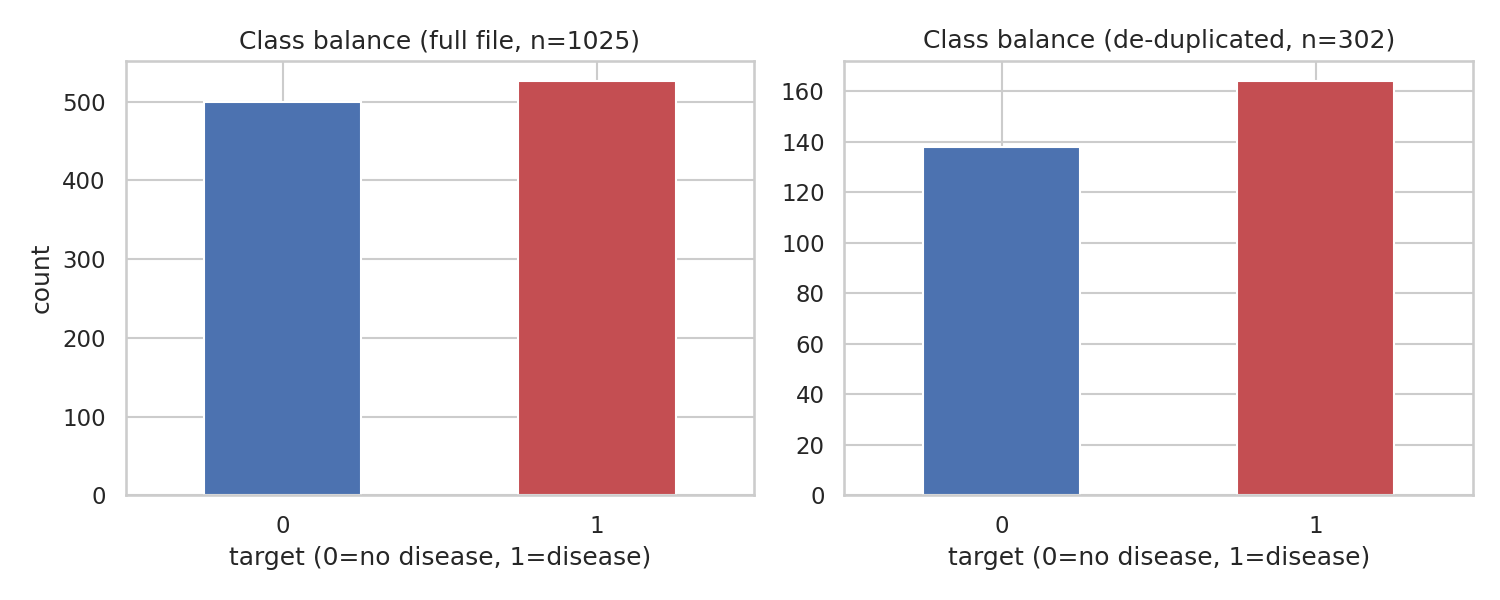

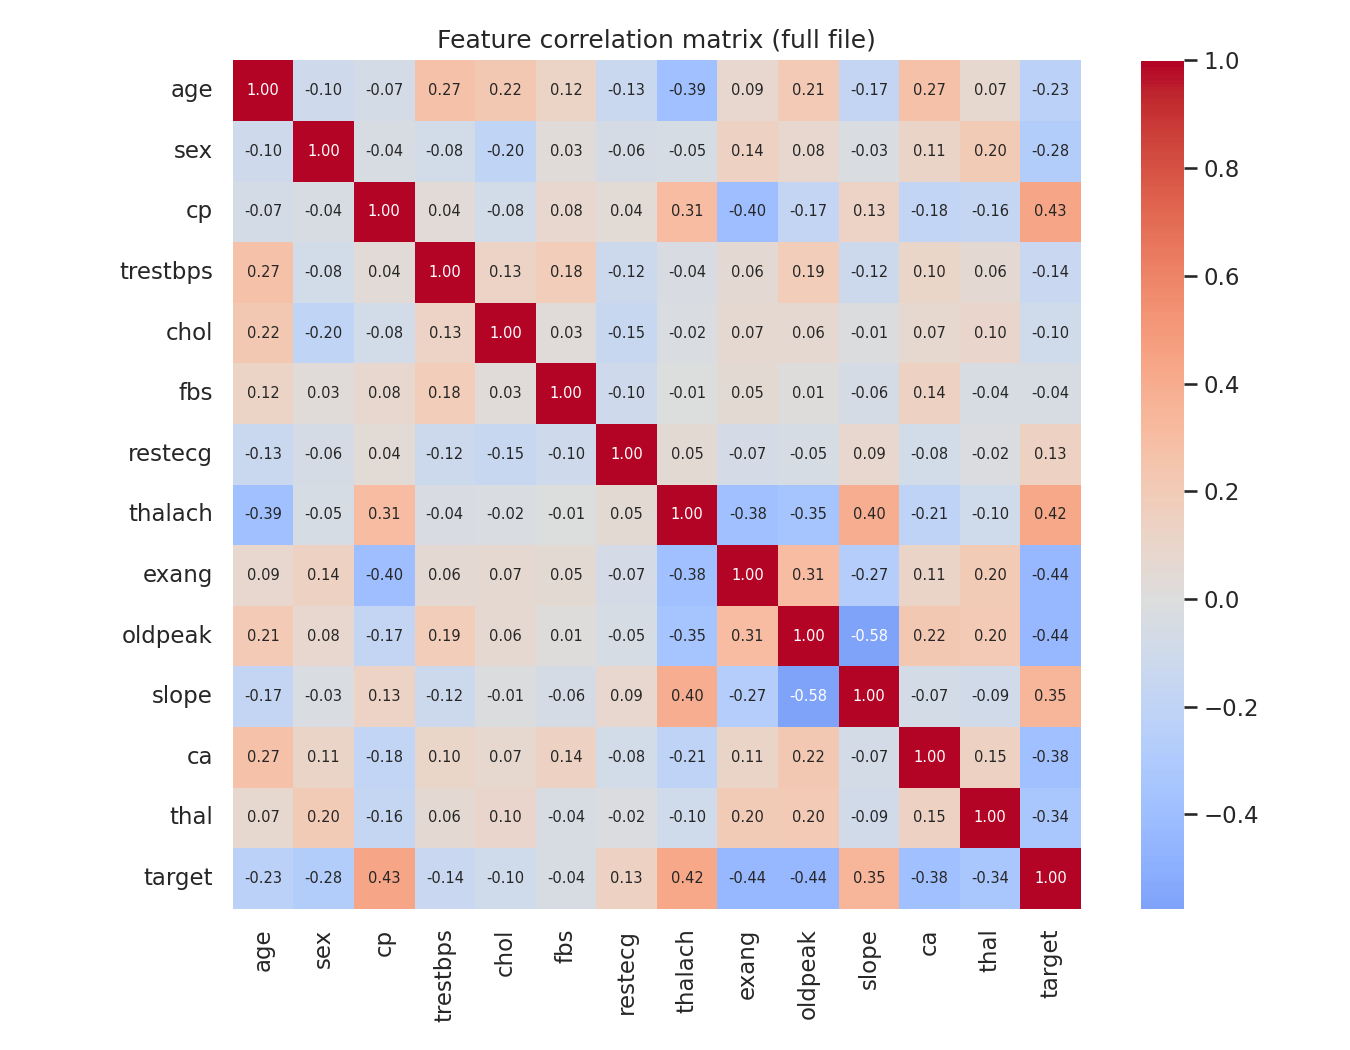

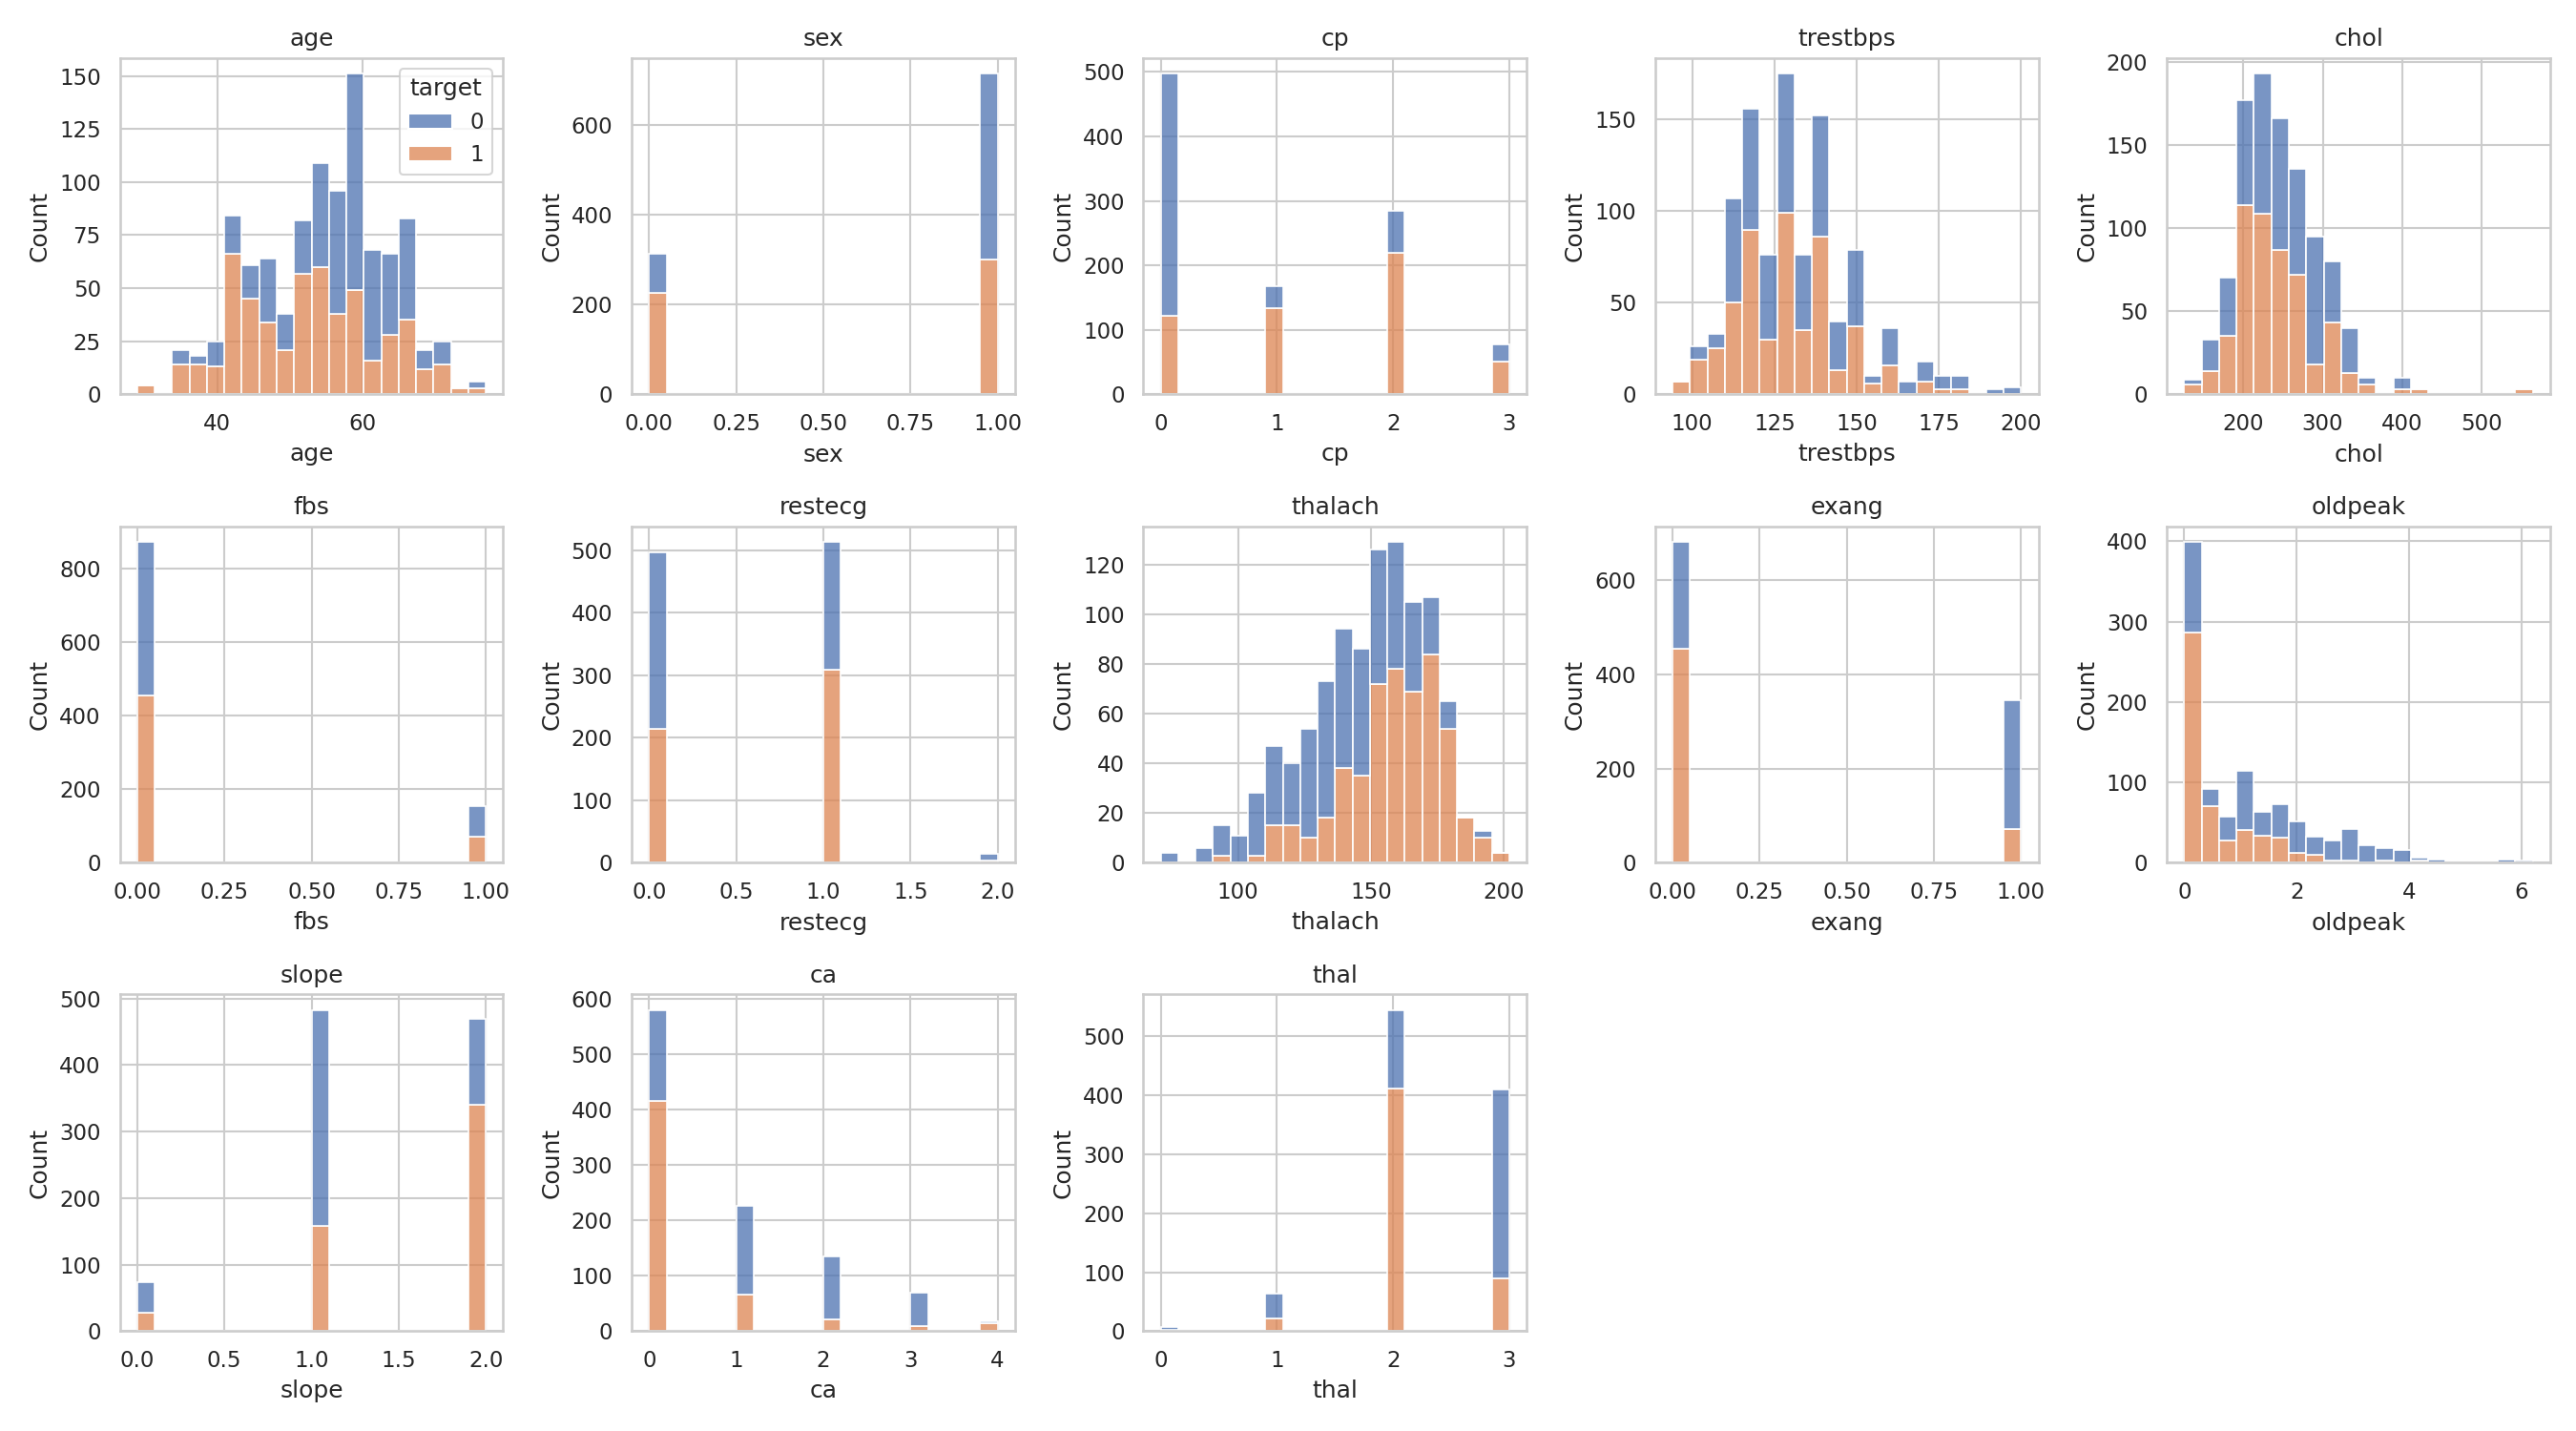

In [5]:
from IPython.display import Image, display
display(Image('../figures/class_balance.png'))
display(Image('../figures/correlation_heatmap.png'))
display(Image('../figures/feature_distributions.png'))

### Key finding
723 of 1025 rows (70.5%) are exact duplicates; only 302 unique rows remain after de-duplication -- essentially the size of the original single-source UCI Cleveland dataset. This is the evidentiary basis for the two-protocol reproduction strategy used in notebook 02.